In [1]:
%load_ext autotime

import scarf
import scarf.plotting as splt

scarf.__version__

'1.0.0'

time: 3.58 s (started: 2026-07-17 01:34:50 +02:00)


In [2]:
scarf.fetch_dataset("tenx_8K_pbmc_citeseq", save_path="scarf_datasets")

time: 19 s (started: 2026-07-17 01:34:54 +02:00)


In [3]:
reader = scarf.CrH5Reader("scarf_datasets/tenx_8K_pbmc_citeseq/data.h5")

time: 16.7 ms (started: 2026-07-17 01:35:11 +02:00)


In [4]:
reader.assayFeats

,RNA,ADT
type,Gene Expression,Antibody Capture
start,0,33538
end,33538,33555
nFeatures,33538,17


time: 5.28 ms (started: 2026-07-17 01:35:11 +02:00)


In [5]:
reader.rename_assays({"assay2": "ADT"})
reader.assayFeats

,RNA,ADT
type,Gene Expression,Antibody Capture
start,0,33538
end,33538,33555
nFeatures,33538,17


time: 3.99 ms (started: 2026-07-17 01:35:11 +02:00)


In [6]:
writer = scarf.CrToZarr(
    reader,
    zarr_loc="scarf_datasets/tenx_8K_pbmc_citeseq/data.zarr",
    chunk_size=(2000, 1000),
)
writer.dump(batch_size=1000)

Writing countsT shape=(33538, 7865) chunks=(33538, 7865)



Writing countsT shape=(17, 7865) chunks=(17, 7865)



time: 1min 7s (started: 2026-07-17 01:35:11 +02:00)


In [7]:
ds = scarf.DataStore(
    "scarf_datasets/tenx_8K_pbmc_citeseq/data.zarr", default_assay="RNA", nthreads=4
)

Minimum cell count (501) is lower than size factor multiplier (1000)



time: 34.6 s (started: 2026-07-17 01:36:15 +02:00)


In [8]:
ds

DataStore has 7865 (7865) cells with 2 assays: RNA ADT
   Cell metadata:
            'I', 'ids', 'names', 'RNA_percentMito', 'ADT_nFeatures', 
            'RNA_percentRibo', 'RNA_nCounts', 'RNA_nFeatures', 'ADT_nCounts'
   RNA assay has 13832 (33538) features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'nCells', 
          
   ADT assay has 17 (17) features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'nCells', 
          

time: 258 ms (started: 2026-07-17 01:36:48 +02:00)


In [9]:
ds.RNA.feats.head()

,I,ids,names,nCells,dropOuts
0,False,ENSG00000243485,MIR1302-2HG,0,7865
1,False,ENSG00000237613,FAM138A,0,7865
2,False,ENSG00000186092,OR4F5,0,7865
3,False,ENSG00000238009,AL627309.1,12,7853
4,False,ENSG00000239945,AL627309.3,0,7865


time: 158 ms (started: 2026-07-17 01:36:49 +02:00)


In [10]:
ds.ADT.feats.head()

,I,ids,names,nCells,dropOuts
0,True,CD3,CD3_TotalSeqB,7864,1
1,True,CD4,CD4_TotalSeqB,7864,1
2,True,CD8a,CD8a_TotalSeqB,7863,2
3,True,CD14,CD14_TotalSeqB,7864,1
4,True,CD15,CD15_TotalSeqB,7864,1


time: 171 ms (started: 2026-07-17 01:36:49 +02:00)


154 cells flagged for filtering out using attribute RNA_nCounts



326 cells flagged for filtering out using attribute RNA_nFeatures



119 cells flagged for filtering out using attribute RNA_percentMito



21 cells flagged for filtering out using attribute RNA_percentRibo



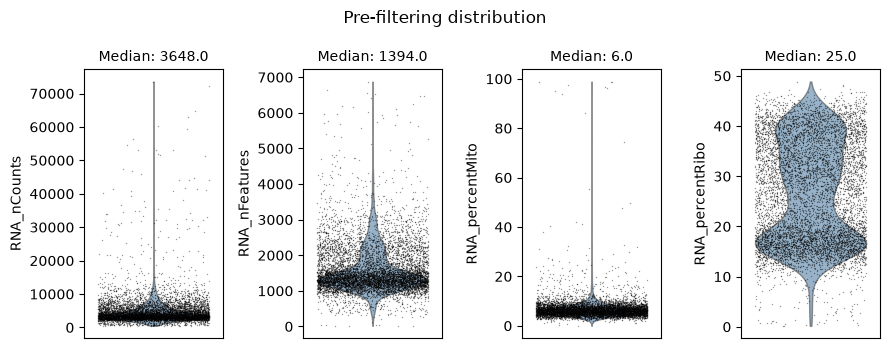

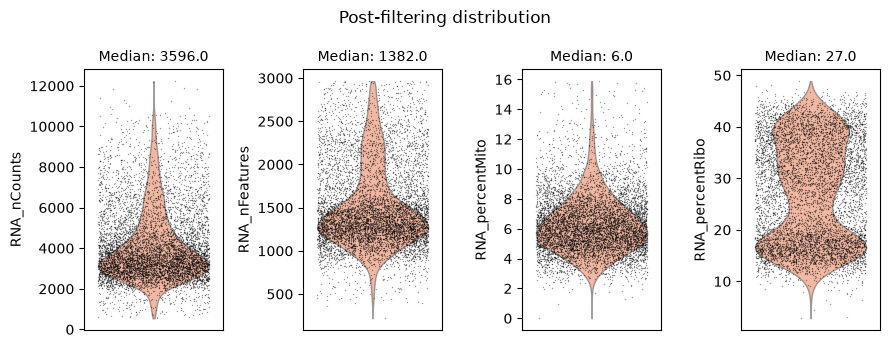

time: 6.27 s (started: 2026-07-17 01:36:49 +02:00)


In [11]:
ds.auto_filter_cells()

Calculating summary statistics



(RNA) feature stats block 1/1: read 4.0s (r2) compute 1.0s rss 992 MiB



Calculating HVGs



997 genes marked as HVGs



/home/parashar/scarf/scarf/plots.py:248: RuntimeWarning: divide by zero encountered in log2
  nzm = np.log2(nzm)
/home/parashar/scarf/scarf/plots.py:249: RuntimeWarning: divide by zero encountered in log2
  fv = np.log2(fv)


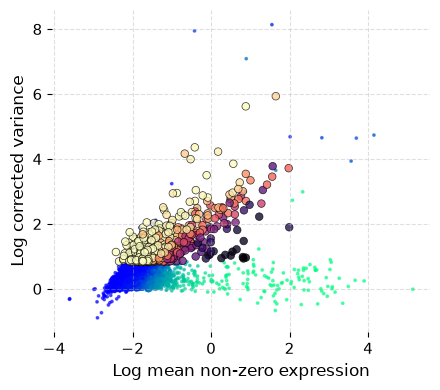

make_graph step 1/7: normalize expression matrix (computing)



make_graph step 1/7: normalize expression matrix finished in 3.4s (computing)



make_graph step 2/7: normalization statistics (computing)



make_graph step 2/7: normalization statistics finished in 0.2s (computing)



make_graph step 3/7: dimension reduction, ANN index, and kmeans (computing)



...

make_graph step 7/7: finalize graph metadata (computing)



make_graph step 7/7: finalize graph metadata finished in 0.0s (computing)



make_graph finished in 25.0s (7/7 steps, 24.9s in logged steps)



Training UMAP:   0%|                                                                                          …

time: 40.9 s (started: 2026-07-17 01:36:55 +02:00)


In [12]:
ds.mark_hvgs(min_cells=20, top_n=1000, min_mean=-3, max_mean=2, max_var=6)

ds.make_graph(feat_key="hvgs", k=21, dims=15, n_centroids=100)

ds.run_umap(n_epochs=250, spread=5, min_dist=1, parallel=True)

ds.run_leiden_clustering(resolution=1)

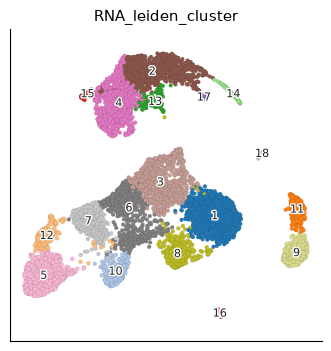

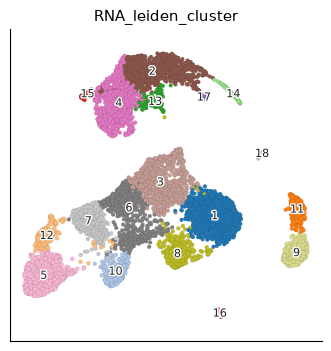

time: 433 ms (started: 2026-07-17 01:37:33 +02:00)


In [13]:
splt.embedding(
    ds,
    layout_key="RNA_UMAP",
    color_by="RNA_leiden_cluster",
    show=False,
).figure

In [14]:
ds.ADT.feats.head(n=ds.ADT.feats.N)

,I,ids,names,nCells,dropOuts
0,True,CD3,CD3_TotalSeqB,7864,1
1,True,CD4,CD4_TotalSeqB,7864,1
2,True,CD8a,CD8a_TotalSeqB,7863,2
3,True,CD14,CD14_TotalSeqB,7864,1
4,True,CD15,CD15_TotalSeqB,7864,1
5,True,CD16,CD16_TotalSeqB,7864,1
6,True,CD56,CD56_TotalSeqB,7864,1
7,True,CD19,CD19_TotalSeqB,7702,163
8,True,CD25,CD25_TotalSeqB,7861,4
9,True,CD45RA,CD45RA_TotalSeqB,7864,1


time: 42 ms (started: 2026-07-17 01:37:33 +02:00)


In [15]:
adt_names = ds.ADT.feats.to_pandas_dataframe(["names"])["names"]
adt_names

0               CD3_TotalSeqB
1               CD4_TotalSeqB
2              CD8a_TotalSeqB
3              CD14_TotalSeqB
4              CD15_TotalSeqB
5              CD16_TotalSeqB
6              CD56_TotalSeqB
7              CD19_TotalSeqB
8              CD25_TotalSeqB
9            CD45RA_TotalSeqB
10           CD45RO_TotalSeqB
11             PD-1_TotalSeqB
12            TIGIT_TotalSeqB
13            CD127_TotalSeqB
14    IgG2a_control_TotalSeqB
15     IgG1_control_TotalSeqB
16    IgG2b_control_TotalSeqB
Name: names, dtype: object

time: 15.9 ms (started: 2026-07-17 01:37:33 +02:00)


In [16]:
is_control = adt_names.str.contains("control").values
is_control

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False,  True,  True,  True])

time: 1.94 ms (started: 2026-07-17 01:37:33 +02:00)


In [17]:
ds.ADT.feats.update_key(~is_control, "I")
ds.ADT.feats.head(n=ds.ADT.feats.N)

,I,ids,names,nCells,dropOuts
0,True,CD3,CD3_TotalSeqB,7864,1
1,True,CD4,CD4_TotalSeqB,7864,1
2,True,CD8a,CD8a_TotalSeqB,7863,2
3,True,CD14,CD14_TotalSeqB,7864,1
4,True,CD15,CD15_TotalSeqB,7864,1
5,True,CD16,CD16_TotalSeqB,7864,1
6,True,CD56,CD56_TotalSeqB,7864,1
7,True,CD19,CD19_TotalSeqB,7702,163
8,True,CD25,CD25_TotalSeqB,7861,4
9,True,CD45RA,CD45RA_TotalSeqB,7864,1


time: 50.7 ms (started: 2026-07-17 01:37:33 +02:00)


In [18]:
print(ds.ADT)
print(ds.ADT.normMethod.__name__)

ADTassay ADT with 14(17) features
norm_clr
time: 9.7 ms (started: 2026-07-17 01:37:33 +02:00)


In [19]:
ds.make_graph(from_assay="ADT", feat_key="I", k=21, dims=0, n_centroids=100)

make_graph step 1/7: normalize expression matrix (computing)



make_graph step 1/7: normalize expression matrix finished in 0.1s (computing)



make_graph step 2/7: normalization statistics (computing)



make_graph step 2/7: normalization statistics finished in 0.0s (computing)



make_graph step 3/7: dimension reduction, ANN index, and kmeans (computing)



...

ANN recall: 99.99%



make_graph step 7/7: finalize graph metadata (computing)



make_graph step 7/7: finalize graph metadata finished in 0.0s (computing)



make_graph finished in 0.7s (7/7 steps, 0.6s in logged steps)



time: 687 ms (started: 2026-07-17 01:37:33 +02:00)


In [20]:
ds.run_umap(from_assay="ADT", n_epochs=250, spread=5, min_dist=1, parallel=True)

ds.run_leiden_clustering(from_assay="ADT", resolution=1)

Training UMAP:   0%|                                                                                          …

time: 4.08 s (started: 2026-07-17 01:37:34 +02:00)


In [21]:
ds.cells.head()

,I,ids,names,RNA_percentMito,ADT_nFeatures,ADT_UMAP1,ADT_UMAP2,ADT_nCounts,RNA_percentRibo,RNA_nFeatures,RNA_leiden_cluster,RNA_nCounts,RNA_UMAP2,RNA_UMAP1,ADT_leiden_cluster
0,True,AAACCCAAGATTGTGA-1,AAACCCAAGATTGTGA-1,8.668831,17.0,-31.930798,-8.257370,981.0,15.259740,2194.0,4,6160.0,19.685101,-8.825310,5
1,True,AAACCCACATCGGTTA-1,AAACCCACATCGGTTA-1,6.316103,17.0,-20.645319,-16.528280,1475.0,19.037688,2093.0,4,6713.0,20.489687,-11.019241,13
2,True,AAACCCAGTACCGCGT-1,AAACCCAGTACCGCGT-1,8.056090,17.0,-27.360403,-17.050976,7149.0,16.002200,1518.0,2,3637.0,29.356348,-4.748739,5
3,True,AAACCCAGTATCGAAA-1,AAACCCAGTATCGAAA-1,9.003215,17.0,23.046974,-26.731216,6831.0,18.729904,737.0,5,1244.0,-22.360479,-27.178730,3
4,True,AAACCCAGTCGTCATA-1,AAACCCAGTCGTCATA-1,6.204519,17.0,24.259558,-24.315113,6839.0,16.353887,1240.0,5,2611.0,-20.658649,-34.788074,3


time: 348 ms (started: 2026-07-17 01:37:38 +02:00)


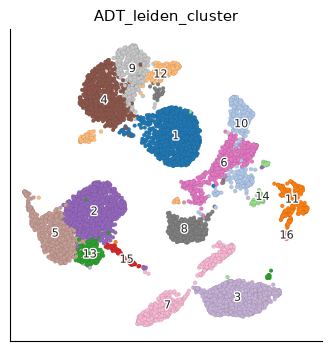

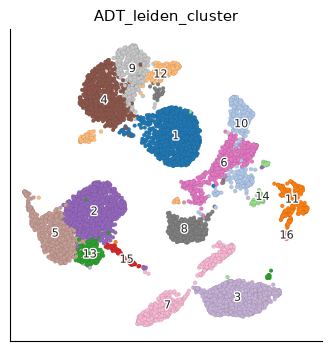

time: 555 ms (started: 2026-07-17 01:37:38 +02:00)


In [22]:
splt.embedding(
    ds,
    layout_key="ADT_UMAP",
    color_by="ADT_leiden_cluster",
    show=False,
).figure

/home/parashar/scarf/scarf/plots.py:849: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  axs.flat[0].figure.show()


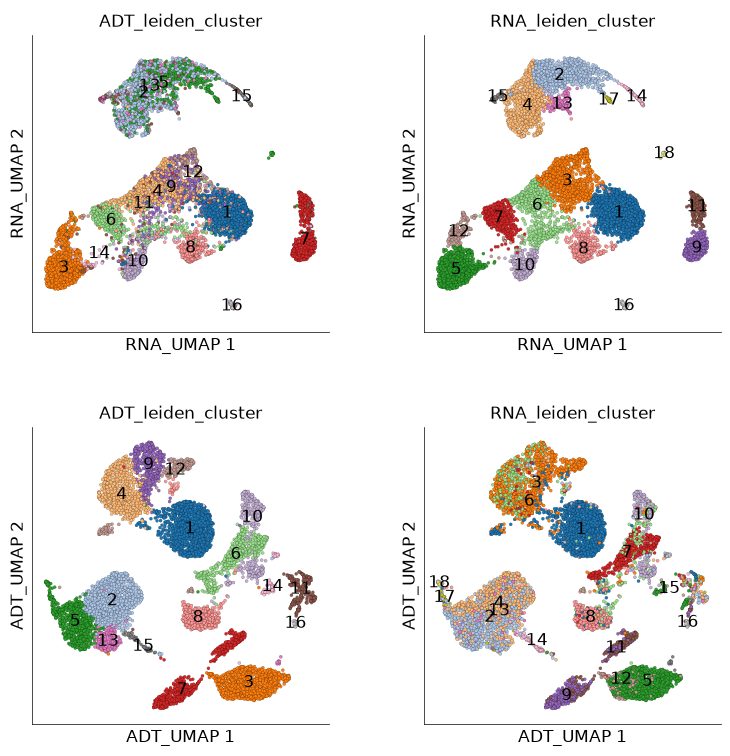

time: 1.49 s (started: 2026-07-17 01:37:39 +02:00)


In [23]:
# UMAP on RNA and coloured with clusters calculated on ADT
ds.plot_layout(
    layout_key=["RNA_UMAP", "ADT_UMAP"],
    color_by=["ADT_leiden_cluster", "RNA_leiden_cluster"],
    cmap="tab20",
    width=4,
    height=4,
    n_columns=2,
    point_size=5,
    legend_onside=False,
)

In [24]:
import pandas as pd

df = pd.crosstab(
    ds.cells.fetch("RNA_leiden_cluster"), ds.cells.fetch("ADT_leiden_cluster")
)
df

col_0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
row_0,,,,,,,,,,,,,,,,
1,1036,0,0,36,3,16,0,31,28,2,17,54,0,0,0,0
2,0,360,1,0,384,3,1,0,3,0,26,1,81,17,5,0
3,33,0,0,367,1,11,1,8,262,15,22,157,0,0,0,0
4,0,566,0,2,175,2,1,0,2,2,33,1,60,7,0,0
5,0,0,732,0,0,0,0,0,1,1,32,0,0,36,1,0
6,4,0,0,277,0,97,0,49,66,64,24,7,0,2,0,0
7,0,0,1,26,0,406,0,6,2,4,14,0,0,2,0,0
8,6,3,0,0,4,24,0,345,1,6,4,4,1,0,0,0
9,0,0,0,0,0,0,315,0,0,0,8,0,0,0,0,0


time: 116 ms (started: 2026-07-17 01:37:40 +02:00)


In [25]:
(100 * df.max() / df.sum()).sort_values(ascending=False)

col_0
16    96.666667
1     94.698355
15    86.956522
3     83.466363
8     77.008929
6     70.000000
10    69.552239
9     69.129288
12    67.672414
5     60.282575
7     60.229446
2     56.998993
4     51.617440
13    50.625000
14    45.569620
11    13.095238
dtype: float64

time: 4.09 ms (started: 2026-07-17 01:37:40 +02:00)


/home/parashar/scarf/scarf/plots.py:849: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  axs.flat[0].figure.show()


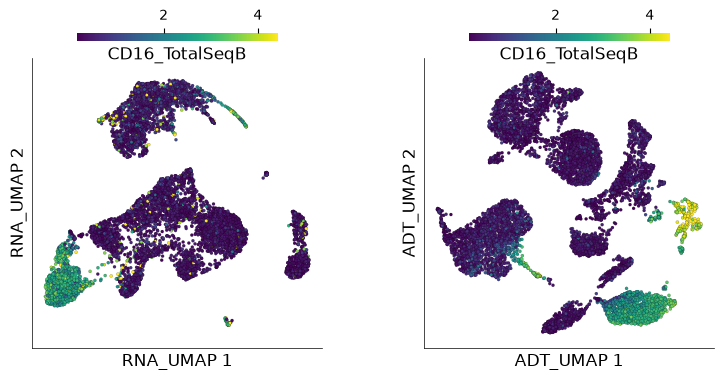

time: 857 ms (started: 2026-07-17 01:37:40 +02:00)


In [26]:
ds.plot_layout(
    layout_key=["RNA_UMAP", "ADT_UMAP"],
    color_by="CD16_TotalSeqB",
    from_assay="ADT",
    width=4,
    height=4,
    n_columns=2,
    point_size=5,
)

/home/parashar/scarf/scarf/plots.py:849: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  axs.flat[0].figure.show()


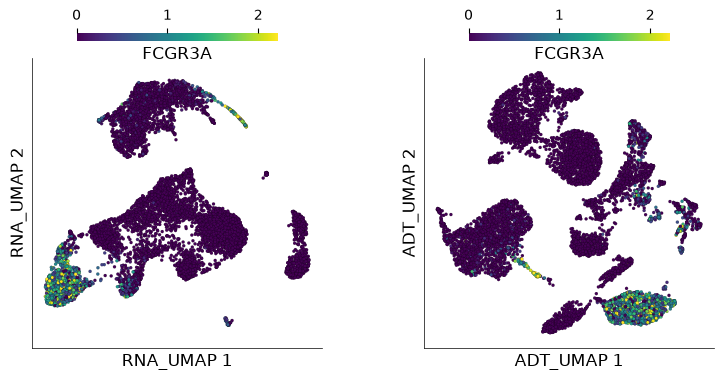

time: 2.75 s (started: 2026-07-17 01:37:41 +02:00)


In [27]:
ds.plot_layout(
    layout_key=["RNA_UMAP", "ADT_UMAP"],
    color_by="FCGR3A",
    from_assay="RNA",
    width=4,
    height=4,
    n_columns=2,
    point_size=5,
)

In [28]:
ds.integrate_assays(assays=["RNA", "ADT"], label="RNA+ADT")

time: 2.91 s (started: 2026-07-17 01:37:44 +02:00)


In [29]:
ds.run_umap(
    integrated_graph="RNA+ADT", n_epochs=500, spread=5, min_dist=0.5, parallel=True
)

ds.run_leiden_clustering(integrated_graph="RNA+ADT", resolution=1.75)

Training UMAP:   0%|                                                                                          …

time: 13 s (started: 2026-07-17 01:37:47 +02:00)


/home/parashar/scarf/scarf/plots.py:849: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  axs.flat[0].figure.show()


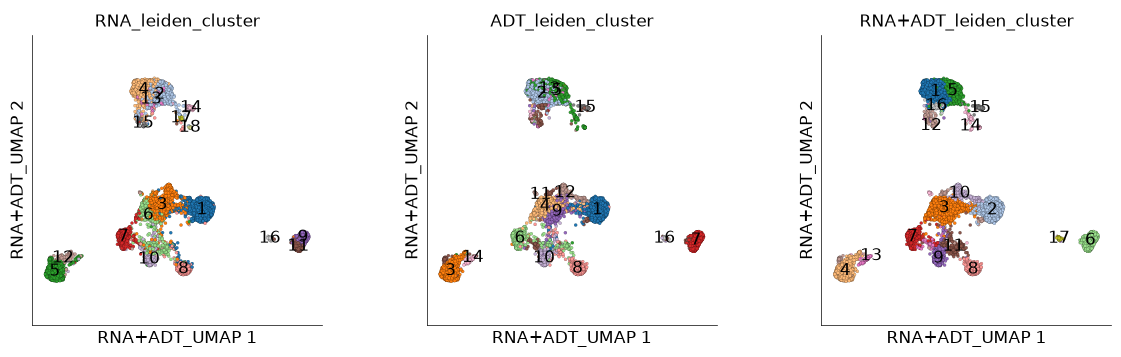

time: 1.71 s (started: 2026-07-17 01:38:00 +02:00)


In [30]:
ds.plot_layout(
    layout_key=["RNA+ADT_UMAP"],
    color_by=["RNA_leiden_cluster", "ADT_leiden_cluster", "RNA+ADT_leiden_cluster"],
    cmap="tab20",
    legend_onside=False,
    point_size=5,
    width=4,
    height=4,
    n_columns=3,
)

In [31]:
ds.cells.columns

['I',
 'ids',
 'names',
 'RNA+ADT_UMAP1',
 'RNA_percentMito',
 'ADT_UMAP2',
 'ADT_nFeatures',
 'ADT_UMAP1',
 'RNA_percentRibo',
 'ADT_nCounts',
 'RNA_nCounts',
 'RNA+ADT_leiden_cluster',
 'RNA+ADT_UMAP2',
 'RNA_nFeatures',
 'RNA_leiden_cluster',
 'ADT_leiden_cluster',
 'RNA_UMAP2',
 'RNA_UMAP1']

time: 20.7 ms (started: 2026-07-17 01:38:00 +02:00)


In [32]:
ds.integrate_assays(assays=["RNA", "ADT"], label="RNA+ADT_wnn", method="wnn")

ds.run_umap(
    integrated_graph="RNA+ADT_wnn", n_epochs=500, spread=5, min_dist=0.5, parallel=True
)

ds.run_leiden_clustering(integrated_graph="RNA+ADT_wnn", resolution=1.75)

make_graph step 1/7: normalize expression matrix (reusing cached)



Using existing normalized data with cell key I and feat key I__hvgs



make_graph step 1/7: normalize expression matrix finished in 0.1s (reusing cached)



make_graph step 2/7: normalization statistics (reusing cached)



make_graph step 2/7: normalization statistics finished in 0.0s (reusing cached)



...

make_graph step 7/7: finalize graph metadata finished in 0.0s (computing)



make_graph finished in 0.3s (7/7 steps, 0.1s in logged steps)



No dimension reduction was user for ADT data. Memory consumption will be high.



Training UMAP:   0%|                                                                                          …

time: 12.3 s (started: 2026-07-17 01:38:00 +02:00)


/home/parashar/scarf/scarf/plots.py:849: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  axs.flat[0].figure.show()


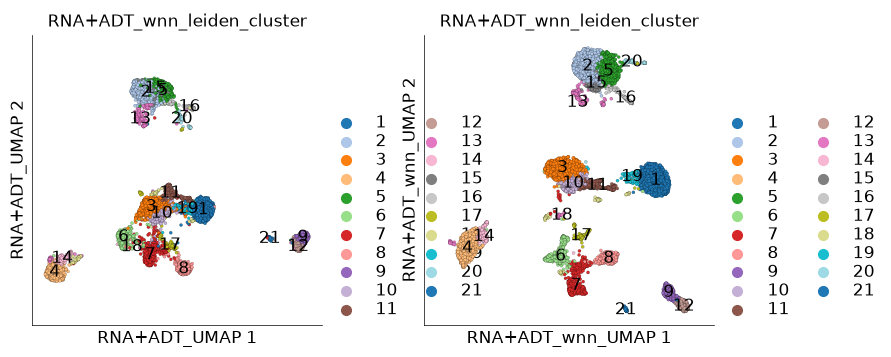

time: 1.47 s (started: 2026-07-17 01:38:12 +02:00)


In [33]:
ds.plot_layout(
    layout_key=["RNA+ADT_UMAP", "RNA+ADT_wnn_UMAP"],
    color_by="RNA+ADT_wnn_leiden_cluster",
    cmap="tab20",
    point_size=5,
    width=4,
    height=4,
    n_columns=2,
)